In [5]:
import numpy as np
import time
import pandas as pd
import matplotlib.pyplot as plt
from ia.GA.model import genetic_algorithm
from ia.GA.utils import nearest_neighbor, two_opt, route_distance
from tqdm import tqdm

In [6]:
# Coordenada de Goiânia
GOIANIA = (-16.6869, -49.2648)

In [7]:
def generate_random_points(n, center=GOIANIA, spread=0.2):
    lat_center, lon_center = center
    latitudes = lat_center + np.random.uniform(-spread, spread, n)
    longitudes = lon_center + np.random.uniform(-spread, spread, n)
    return list(zip(latitudes, longitudes))

In [8]:
points = generate_random_points(3)
ga_route, ga_distance = genetic_algorithm(points, GOIANIA) # Used to initialize the functions with numba, so that they can be used later

In [9]:
min_points = 10
max_points = 50
step = 1

results = []
r_values = []

x_points = []
y_nn, y_2opt, y_ga = [], [], []
print(f"Testing algorithms with points from {min_points} to {max_points} in steps of {step}...")

Testing algorithms with points from 10 to 50 in steps of 1...


In [10]:
for n_points in tqdm(range(min_points, max_points + 1, step)):
    points = generate_random_points(n_points)
    x_points.append(n_points)

    # NN
    start = time.time()
    nn_route, dist_matrix = nearest_neighbor(GOIANIA, np.array(points))
    nn_distance = route_distance(nn_route, dist_matrix)
    nn_time = time.time() - start

    # 2-Opt
    start = time.time()
    opt_route = two_opt(nn_route, dist_matrix)
    opt_distance = route_distance(opt_route, dist_matrix)
    opt_time = time.time() - start + nn_time

    # GA
    start = time.time()
    ga_route, ga_distance = genetic_algorithm(points, GOIANIA)
    ga_time = time.time() - start

    # Melhora percentual
    opt_improvement = 100 * (nn_distance - opt_distance) / nn_distance
    ga_improvement = 100 * (nn_distance - ga_distance) / nn_distance

    y_nn.append(nn_distance)
    y_2opt.append(opt_distance)
    y_ga.append(ga_distance)

    results.append([
        n_points,
        round(nn_distance, 2), f"{nn_time:.2f}s",
        round(opt_distance, 2), f"{opt_time:.2f}s", f"{opt_improvement:.1f}%",
        round(ga_distance, 2), f"{ga_time:.2f}s", f"{ga_improvement:.1f}%"
    ])
    r_values.append([
        nn_distance, nn_time,
        opt_distance, opt_time, opt_improvement,
        ga_distance, ga_time, ga_improvement
    ])

100%|██████████| 41/41 [02:32<00:00,  3.72s/it]


In [11]:
results.append([
    "Média",
    f"{np.mean([r[0] for r in r_values]):.2f}", f"{np.mean([r[1] for r in r_values]):.2f}s",
    f"{np.mean([r[2] for r in r_values]):.2f}", f"{np.mean([r[3] for r in r_values]):.2f}s", f"{np.mean([r[4] for r in r_values]):.1f}%",
    f"{np.mean([r[5] for r in r_values]):.2f}", f"{np.mean([r[6] for r in r_values]):.2f}s", f"{np.mean([r[7] for r in r_values]):.2f}%"
])

In [12]:
headers = [
    "N Points",
    "NN Dist", "NN Time",
    "2Opt Dist", "2Opt Time", "2Opt %↓",
    "GA Dist", "GA Time", "GA %↓"
]

df_results = pd.DataFrame(results, columns=headers)
display(df_results)

,N Points,NN Dist,NN Time,2Opt Dist,2Opt Time,2Opt %↓,GA Dist,GA Time,GA %↓
0,10,284.83,1.32s,253.6,2.25s,11.0%,246.11,1.21s,13.6%
1,11,328.76,1.12s,277.42,1.12s,15.6%,277.42,1.21s,15.6%
2,12,193.85,1.48s,183.46,1.48s,5.4%,177.86,1.20s,8.2%
3,13,305.35,1.12s,270.52,1.12s,11.4%,263.65,2.32s,13.7%
4,14,259.89,1.13s,235.99,1.13s,9.2%,228.87,1.23s,11.9%
5,15,320.09,1.15s,292.28,1.15s,8.7%,292.26,1.25s,8.7%
6,16,218.28,6.14s,209.17,6.14s,4.2%,204.5,1.26s,6.3%
7,17,229.7,1.09s,213.08,1.09s,7.2%,212.96,1.27s,7.3%
8,18,301.07,1.12s,273.27,1.12s,9.2%,271.33,1.24s,9.9%
9,19,339.89,1.96s,322.53,1.96s,5.1%,312.89,1.24s,7.9%


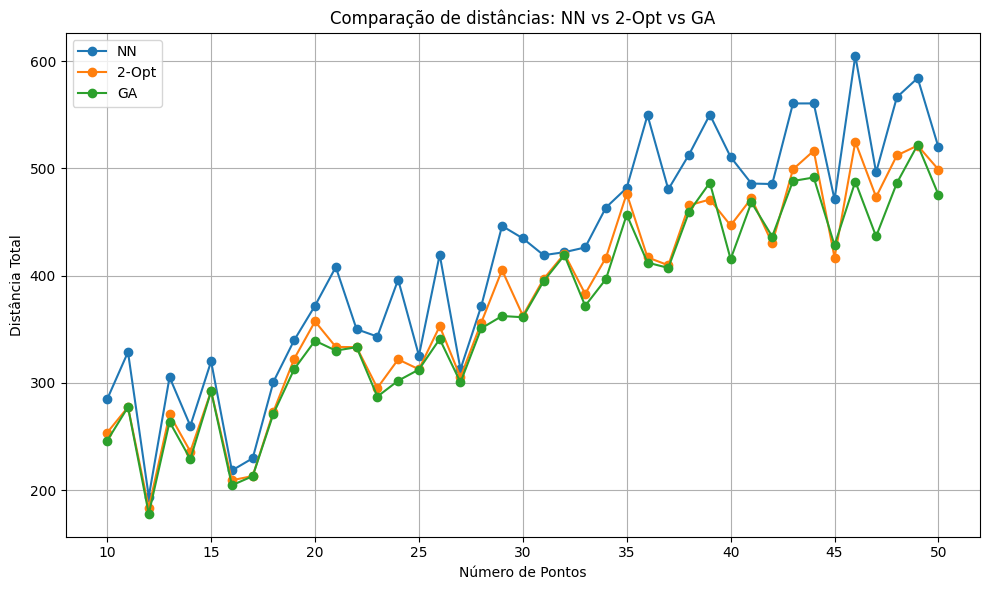

In [13]:
plt.figure(figsize=(10, 6))
plt.plot(x_points, y_nn, label='NN', marker='o')
plt.plot(x_points, y_2opt, label='2-Opt', marker='o')
plt.plot(x_points, y_ga, label='GA', marker='o')
plt.xlabel('Número de Pontos')
plt.ylabel('Distância Total')
plt.title('Comparação de distâncias: NN vs 2-Opt vs GA')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()